<a href="https://colab.research.google.com/github/G1G1KO/Calorie-Burn-Predictor/blob/main/Calorie_Burn_Predictor.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

--- Model Performance Report ---
Model Accuracy (R-squared): 98.10%
Mean Absolute Error: 7.41 Calories
--------------------------------


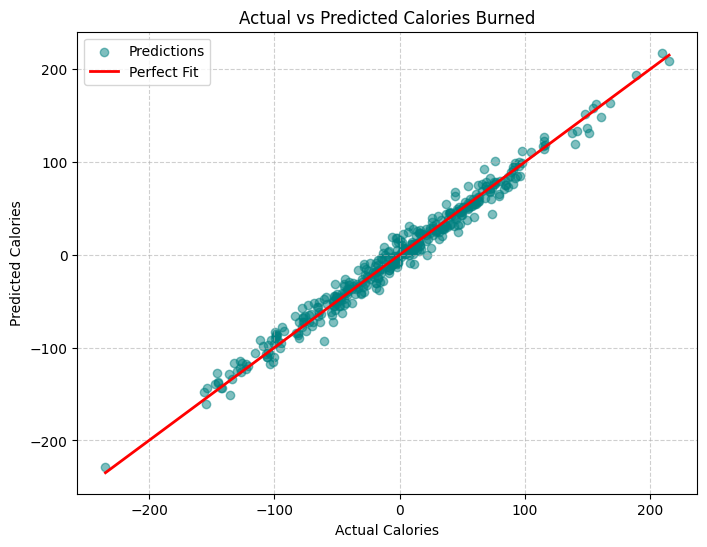

In [13]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.datasets import make_regression
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import r2_score, mean_absolute_error

# 1. DATA PREPARATION
# 2000 samples with 5 features (e.g., Age, Gender, Duration, Heart Rate, Body Temp)
X, y = make_regression(n_samples=2000, n_features=5, noise=10, random_state=42)
y = y.reshape(-1, 1)

# Split and Scale
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)
scaler = StandardScaler()
X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

# 2. THE NUMPY MODEL CLASS
class CaloriePredictor:
    def __init__(self, learning_rate=0.1, iterations=1000):
        self.lr = learning_rate
        self.epochs = iterations
        self.weights = None
        self.bias = None

    def fit(self, X, y):
        n_samples, n_features = X.shape
        self.weights = np.zeros((n_features, 1))
        self.bias = 0

        for _ in range(self.epochs):
            y_pred = np.dot(X, self.weights) + self.bias

            # Gradient Descent Calculation
            dw = (1/n_samples) * np.dot(X.T, (y_pred - y))
            db = (1/n_samples) * np.sum(y_pred - y)

            # Update Parameters
            self.weights -= self.lr * dw
            self.bias -= self.lr * db

    def predict(self, X):
        return np.dot(X, self.weights) + self.bias

# 3. TRAINING
model = CaloriePredictor(learning_rate=0.1, iterations=1000)
model.fit(X_train, y_train)

# 4. FINAL PERFORMANCE METRICS & VISUALIZATION
predictions = model.predict(X_test)

# Accuracy Metrics
accuracy_r2 = r2_score(y_test, predictions)
mae = mean_absolute_error(y_test, predictions)

print("--- Model Performance Report ---")
print(f"Model Accuracy (R-squared): {accuracy_r2 * 100:.2f}%")
print(f"Mean Absolute Error: {mae:.2f} Calories")
print("--------------------------------")

# 5. VISUALIZING ACTUAL VS. PREDICTED

plt.figure(figsize=(8, 6))
plt.scatter(y_test, predictions, alpha=0.5, color='teal', label='Predictions')
# Diagonal line representing perfect prediction
plt.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], color='red', lw=2, label='Perfect Fit')
plt.title('Actual vs Predicted Calories Burned')
plt.xlabel('Actual Calories')
plt.ylabel('Predicted Calories')
plt.legend()
plt.grid(True, linestyle='--', alpha=0.6)
plt.show()